<a href="https://www.pieriandata.com"><img src="data/Logo.jpg"></a>

# Blending and Pasting Images

For some computer vision systems, we'll want to be able to post our own image on top of an already existing image or video. We may also want to blend images, maybe we want to have a "highlight" effect instead of just a solid box or empty rectangle.

Let's explore what is commonly known as **Arithmetic Image Operations** with OpenCV. These are referred to as Arithmetic Operations because OpenCV is simply performing some common math with the pixels for the final effect. We'll see a bit of this in our code.

## Blending Images

Blending Images is actually quite simple, let's look at a simple example.

In [1]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
img1 = cv2.imread('data/dog_backpack.png')
img2 = cv2.imread('data/watermark_no_copy.png')

In [4]:
img1.shape, img2.shape

((1401, 934, 3), (1280, 1277, 3))

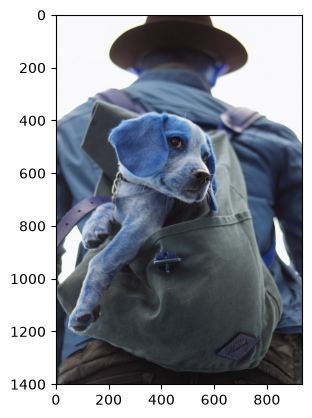

In [5]:
plt.imshow(img1)

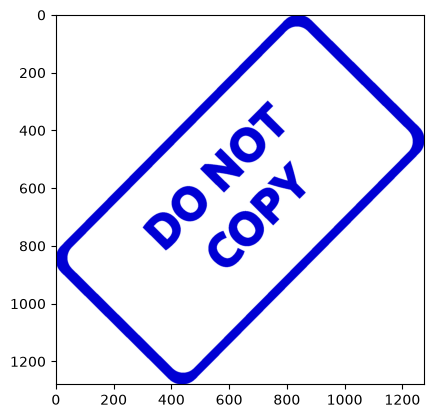

In [6]:
plt.imshow(img2)

Whoops! Let's remember to fix the RGB!

In [7]:
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

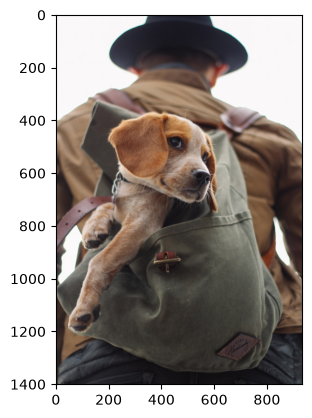

In [8]:
plt.imshow(img1)

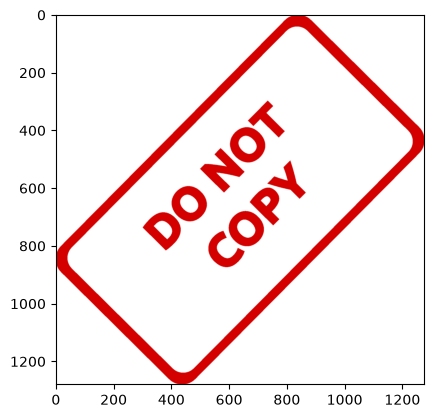

In [9]:
plt.imshow(img2)

### Resizing the Images

In [10]:
img1 = cv2.resize(img1, (1200,1200))
img2 = cv2.resize(img2, (1200,1200))

Let's practice resizing the image, since the DO NOT COPY image is actually quite large 1200 by 1200, and our puppy in backpack image is 1400 by 1000

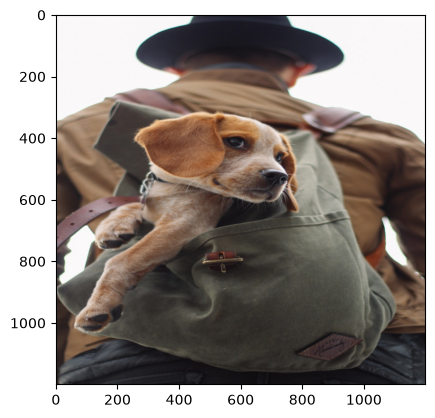

In [11]:
plt.imshow(img1)

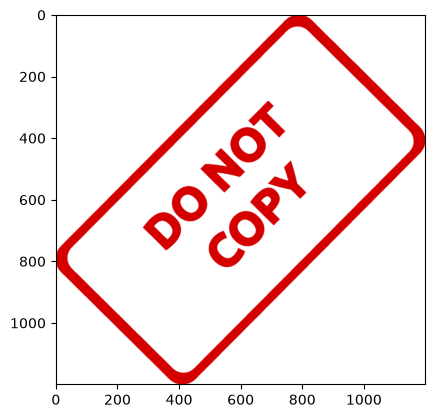

In [12]:
plt.imshow(img2)

### Blending the Image

We will blend the values together with the formula:

$$\boxed {\text{new image} = (\alpha * \text{image}_1) + (\beta * \text{image}_2) + \gamma}$$

In [13]:
img1.shape, img2.shape

((1200, 1200, 3), (1200, 1200, 3))

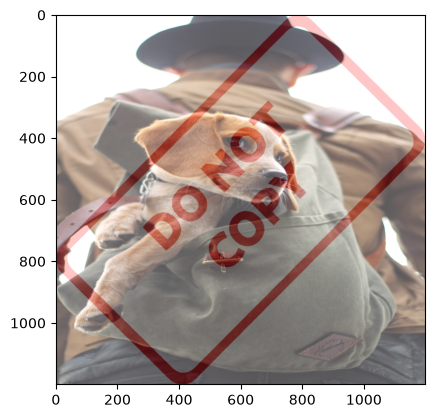

In [29]:
blended_img = cv2.addWeighted(src1=img1, alpha=0.8, src2=img2, beta=0.3, gamma=0)
plt.imshow(blended_img)

-----

## Overlaying Images of Different Sizes

We can use this quick trick to quickly overlap different sized images, by simply reassigning the larger image's values to match the smaller image.

In [30]:
img1 = cv2.imread('data/dog_backpack.png')
img2 = cv2.imread('data/watermark_no_copy.png')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

img2 = cv2.resize(img2, (600, 600))

large_img = img1
small_img = img2

In [31]:
x_offset = 0
y_offset = 0

In [37]:
large_img.shape, small_img.shape

((1401, 934, 3), (600, 600, 3))

The dimension of the `(1401, 934, 3)` means:  

```text
(height, width, channels)
  1401    934      3
   ↓       ↓       ↓
   Y       X    RGB/BGR
```

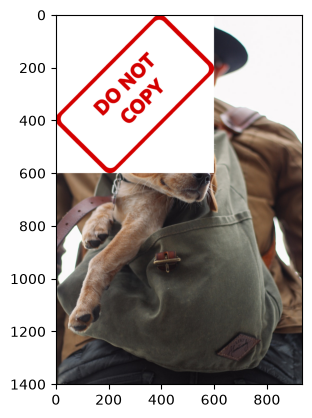

In [39]:
large_img[y_offset: y_offset + small_img.shape[0], x_offset:x_offset + small_img.shape[1]] = small_img
plt.imshow(large_img)

___

## Blending Images of Different Sizes

### Imports

In [40]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

### Importing the images again and resizing

In [93]:
img1 = cv2.imread('data/dog_backpack.png')
img2 = cv2.imread('data/watermark_no_copy.png')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

img2 = cv2.resize(img2, (600, 600))

large_img = img1
small_img = img2

(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

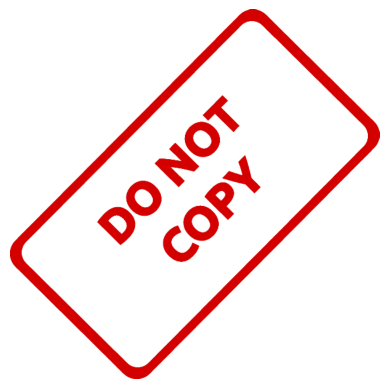

In [95]:
plt.imshow(img2)
plt.axis('off')

### Create a Region of Interest (ROI)

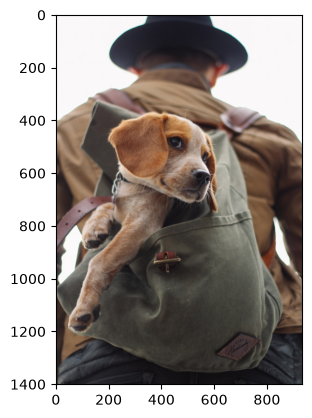

In [44]:
plt.imshow(img1)

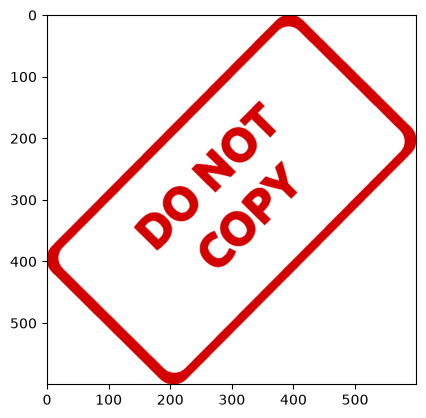

In [45]:
plt.imshow(img2)

In [42]:
large_img.shape, small_img.shape

((1401, 934, 3), (600, 600, 3))

In [43]:
x_offset = 934 - 600
y_offset = 1401 - 600

In [ ]:
# Creating an ROI of the same size of the foreground image (smaller image that will go on top)
# TOP LEFT CORNER
# rows, cols, channels = img2.shape
# roi = img1[0:rows, 0:cols]

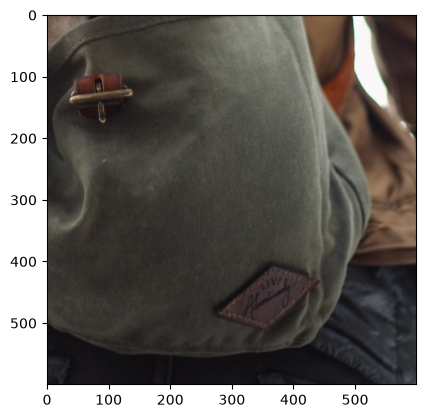

In [46]:
# BOTTOM RIGHT CORNER
roi = img1[y_offset: 1401, x_offset:934]
plt.imshow(roi)

In [47]:
roi.shape

(600, 600, 3)

### Creating a Mask

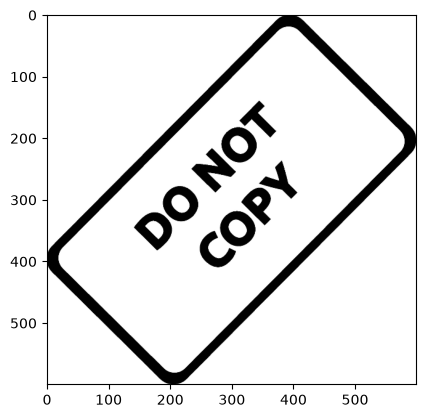

In [49]:
# Create a mask of logo
img2gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
plt.imshow(img2gray, cmap='gray')

In [52]:
img2gray.shape # Converted to 2 dimension

(600, 600)

`cv2.bitwise_not()` $\Rightarrow$ $\boxed {\text{new pixel} = 255 - \text{original pixel}}$

In [56]:
mask_inv = cv2.bitwise_not(img2gray)

In [57]:
mask_inv.shape

(600, 600)

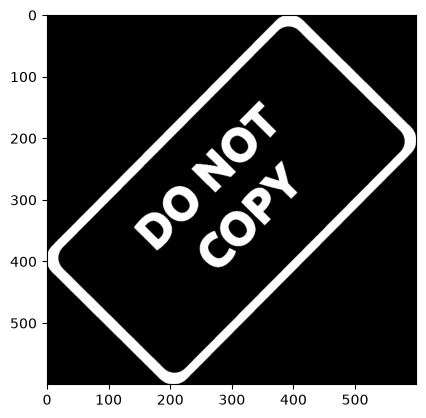

In [60]:
plt.imshow(mask_inv, cmap='gray')

## Convert Mask to have 3 channels

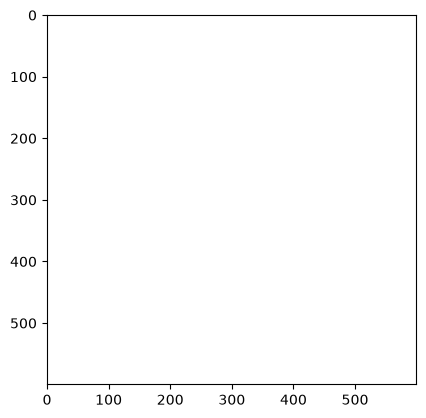

In [67]:
white_bg = np.full(shape=img2.shape, fill_value=255, dtype=np.uint8) # White blank image
plt.imshow(white_bg)

> "Copy the pixels from `white_bg` to `bk` only at the locations where `mask_inv` is **non-zero**."

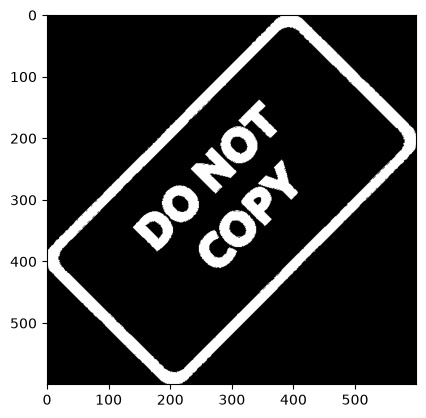

In [69]:
bk = cv2.bitwise_or(white_bg, white_bg, mask=mask_inv)
plt.imshow(bk)

In [70]:
bk.shape

(600, 600, 3)

### Grab Original FG image and place on top of Mask

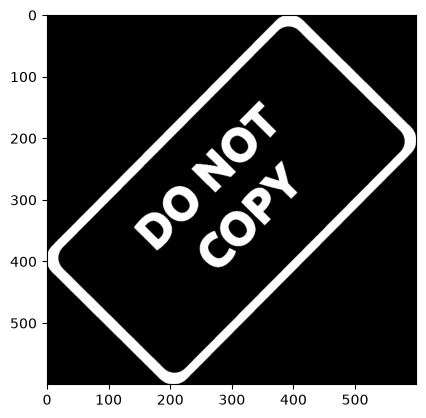

In [71]:
plt.imshow(mask_inv, cmap='gray')

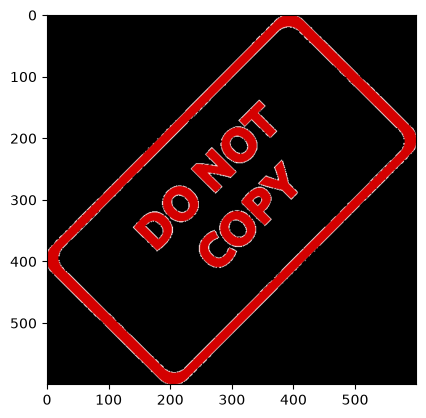

In [76]:
fg = cv2.bitwise_or(img2, img2, mask=mask_inv)
plt.imshow(fg)

In [77]:
fg.shape

(600, 600, 3)

### Get ROI and blend in the mask with the ROI

In [88]:
final_roi = cv2.bitwise_or(roi, fg)

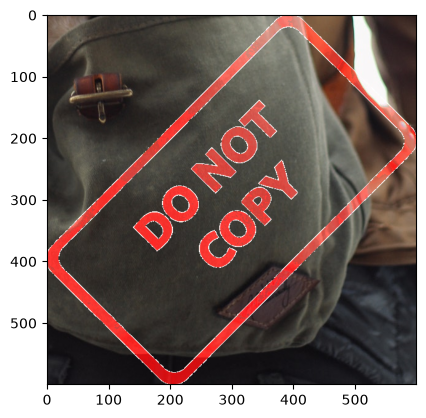

In [89]:
plt.imshow(final_roi)

### Now add in the rest of the image

In [90]:
large_img = img1
small_img = final_roi

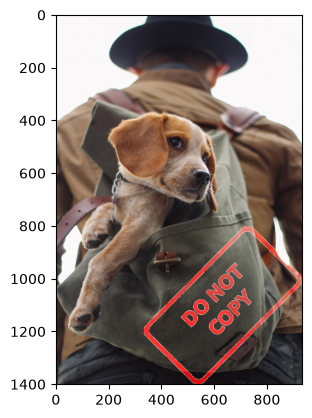

In [91]:
large_img[y_offset:y_offset+small_img.shape[0], x_offset:x_offset+small_img.shape[1]] = small_img
plt.imshow(large_img)

### Great Work!

Check out these documentation examples and links for more help for these kinds of tasks (which can be really tricky!)

1. https://stackoverflow.com/questions/10469235/opencv-apply-mask-to-a-color-image/38493075
2. https://stackoverflow.com/questions/14063070/overlay-a-smaller-image-on-a-larger-image-python-opencv
3. https://docs.opencv.org/3.4/d0/d86/tutorial_py_image_arithmetics.html